# 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset (change path if necessary)
## Example: Titanic dataset from Seaborn or Kaggle

In [13]:
try:
    df = sns.load_dataset('titanic')
except Exception:
# fallback: user should place titanic.csv in working directory
    df = pd.read_csv('titanic.csv')

# 3. Quick overview

In [15]:
print('Shape:', df.shape)
print(df.head())

Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# 4. Missing values

In [18]:
print('\nMissing values:')
print(df.isnull().sum())


Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


# 5. Univariate analysis

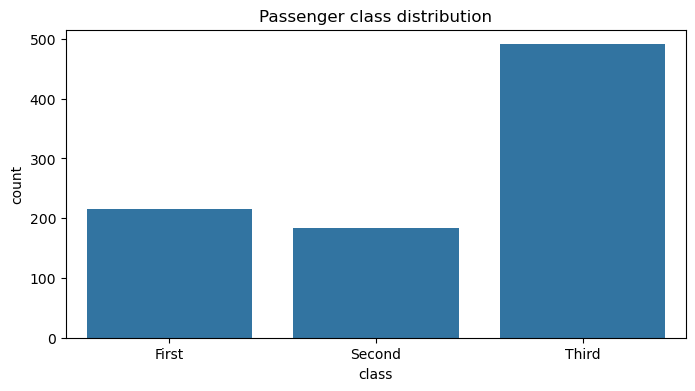

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(x='class', data=df)
plt.title('Passenger class distribution')
plt.show()

# 6. Age distribution

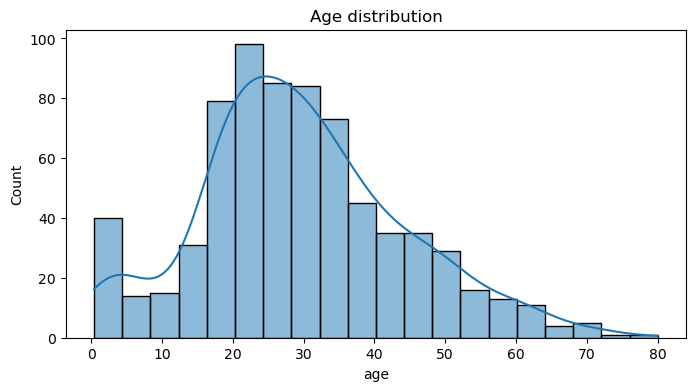

In [24]:
plt.figure(figsize=(8,4))
sns.histplot(df['age'].dropna(), kde=True)
plt.title('Age distribution')
plt.show()

# 7. Bivariate: survival vs class

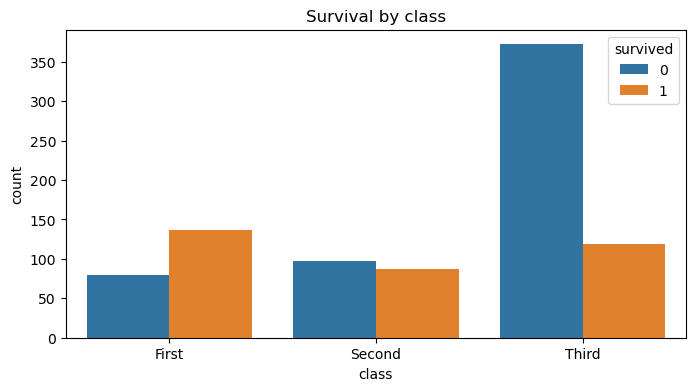

In [27]:
plt.figure(figsize=(8,4))
sns.countplot(x='class', hue='survived', data=df)
plt.title('Survival by class')
plt.show()

# 8. Correlation heatmap for numeric features

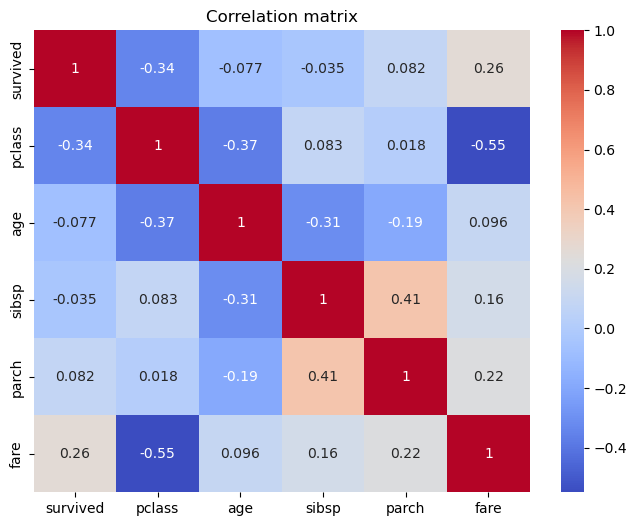

In [30]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

# 9. Simple feature engineering: family size

In [35]:
if 'sibsp' in df.columns and 'parch' in df.columns:
    df['family_size'] = df['sibsp'] + df['parch']
    print('\nCreated family_size column')


Created family_size column


# 10. Export summary

In [39]:
summary = df.describe(include='all')
summary.to_csv('eda_summary.csv')
print('\nEDA summary exported to eda_summary.csv')


EDA summary exported to eda_summary.csv
